In [33]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

<module 'utilities.plot' from '/Users/xuechenkan/potts_model_test/ms1/../utilities/plot.py'>

In [34]:
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

In [35]:
IN_double_mutation = "C140D-D148B"
pair1, pair2 = functions.split_pairs(IN_double_mutation)
wt1,pos1,mt1 = functions.split_pair(pair1)
wt2,pos2,mt2 = functions.split_pair(pair2)
IN_seq_w_mutation = [seq for seq in IN_all_seq if seq[pos1-1] == mt1 and seq[pos2-1] == mt2]
print(len(IN_seq_w_mutation))

221


In [36]:
p_SH_all = [functions.calculate_double_mutant_probablity(seq, 'C140D', 'D148B', IN_J, 1, 263) for seq in IN_seq_w_mutation]
lowest_prob_indices = sorted(range(len(p_SH_all)), key=p_SH_all.__getitem__)[:10]
highest_prob_indices = sorted(range(len(p_SH_all)), key=p_SH_all.__getitem__, reverse=True)[:10]

print("10 lowest probability indices:", lowest_prob_indices)
print("10 highest probability indices:", highest_prob_indices)


10 lowest probability indices: [47, 4, 25, 19, 44, 216, 203, 219, 43, 123]
10 highest probability indices: [172, 193, 55, 92, 210, 70, 0, 88, 190, 74]


In [37]:
min_position = 1
max_position = 263

print("Lowest probability indices and values:", [(i, p_SH_all[i]) for i in lowest_prob_indices])
print("Highest probability indices and values:", [(i, p_SH_all[i]) for i in highest_prob_indices])

Lowest probability indices and values: [(47, 0.007800793463008116), (4, 0.028399198721585844), (25, 0.03629026601253644), (19, 0.05293623759243532), (44, 0.061805707433160474), (216, 0.06347403329018718), (203, 0.08040587285169684), (219, 0.09282344926178461), (43, 0.09960123704315765), (123, 0.1073738893249246)]
Highest probability indices and values: [(172, 0.9920179375618225), (193, 0.9916040563588459), (55, 0.9907137598656011), (92, 0.9865013227062998), (210, 0.985960115614258), (70, 0.9767480412742192), (0, 0.9730512870129445), (88, 0.9729018823109195), (190, 0.9721211738209948), (74, 0.9661677256170271)]


In [56]:
vectors_top10 = [functions.vectorize_seq_residue_energy(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in highest_prob_indices]
vectors_bottom10 = [functions.vectorize_seq_residue_energy(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in lowest_prob_indices]
print(sum(vectors_top10[0])/2)
print(sum(vectors_bottom10[0])/2)

-1553.3956
-1530.8302


In [ ]:
# # verify vectorization on consensus sequence
# consensus_E = functions.calculate_e(IN_consensus_seq, IN_J, min_position, max_position)
# print(consensus_E)

# consensus_residue_E_vector = functions.vectorize_seq_residue_energy(IN_consensus_seq, IN_J, min_position, max_position)
# print(sum(consensus_residue_E_vector)/2)


-1557.7028
-1557.7023


In [ ]:
# #verify E values for top and bottom sequences
# E_top10 = [functions.calculate_e(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in highest_prob_indices]
# E_bottom10 = [functions.calculate_e(IN_seq_w_mutation[i], IN_J, min_position, max_position) for i in lowest_prob_indices]
# print("E values for top 10 highest probability sequences:", E_top10)
# print("E values for top 10 lowest probability sequences:", E_bottom10)

E values for top 10 highest probability sequences: [np.float32(-1553.3955), np.float32(-1552.9882), np.float32(-1553.1445), np.float32(-1548.2047), np.float32(-1553.0416), np.float32(-1552.6156), np.float32(-1546.2645), np.float32(-1552.0209), np.float32(-1551.9121), np.float32(-1549.5916)]
E values for top 10 lowest probability sequences: [np.float32(-1530.8325), np.float32(-1545.7522), np.float32(-1539.1858), np.float32(-1549.174), np.float32(-1541.0706), np.float32(-1538.3734), np.float32(-1541.6165), np.float32(-1550.8226), np.float32(-1545.3658), np.float32(-1543.6357)]


Explained variance ratio: [0.14019193 0.10752875]


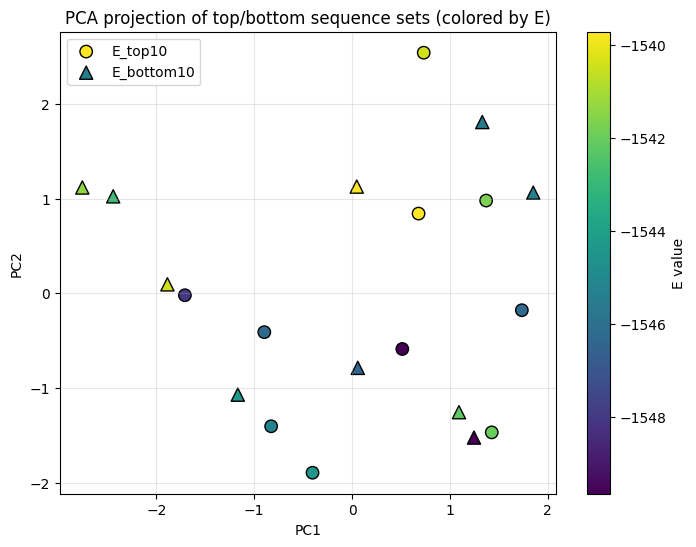

In [41]:
import numpy as np
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# Use the same sequences that generated E_top10 and E_bottom10
top_seqs = [IN_all_seq[i] for i in highest_prob_indices]
bottom_seqs = [IN_all_seq[i] for i in lowest_prob_indices]

all_seqs = top_seqs + bottom_seqs
labels = np.array(["E_top10"] * len(top_seqs) + ["E_bottom10"] * len(bottom_seqs))
E_vals = np.array(E_top10 + E_bottom10)

# One-hot encode reduced sequences (A/B/C/D, etc.)
alphabet = sorted(set("".join(all_seqs)))
char_to_idx = {c: i for i, c in enumerate(alphabet)}
L = len(all_seqs[0])
A = len(alphabet)

X = np.zeros((len(all_seqs), L * A), dtype=float)
for n, seq in enumerate(all_seqs):
    for pos, ch in enumerate(seq):
        X[n, pos * A + char_to_idx[ch]] = 1.0

# PCA projection to 2D
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot: marker = group, color = E value
plt.figure(figsize=(8, 6))

top_mask = labels == "E_top10"
bottom_mask = labels == "E_bottom10"

sc1 = plt.scatter(
    X_pca[top_mask, 0], X_pca[top_mask, 1],
    c=E_vals[top_mask], cmap="viridis", marker="o", s=80, edgecolor="k", label="E_top10"
)
plt.scatter(
    X_pca[bottom_mask, 0], X_pca[bottom_mask, 1],
    c=E_vals[bottom_mask], cmap="viridis", marker="^", s=90, edgecolor="k", label="E_bottom10"
)

cbar = plt.colorbar(sc1)
cbar.set_label("E value")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of top/bottom sequence sets (colored by E)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Encoded energy vectors shape: (2, 10)
PCA result shape: (2, 2)
Explained variance ratio: [1.00000000e+00 6.33967397e-33]
PCA coordinates [top10, bottom10]:
 [[ 1.64430275e+00  1.30922788e-16]
 [-1.64430275e+00  1.30922788e-16]]


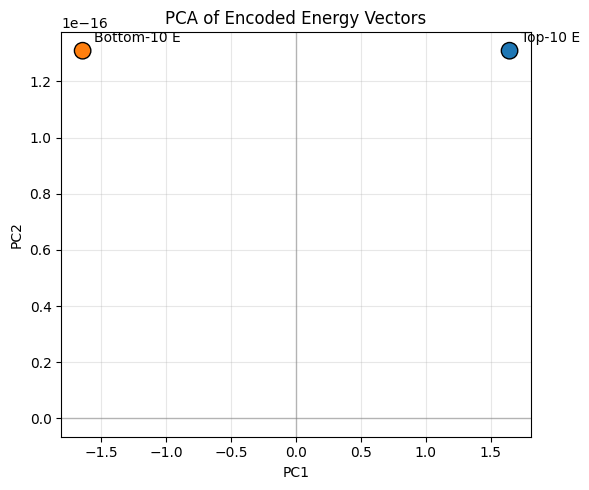

In [42]:
# Build strictly 2 vectors: top-10 energies and bottom-10 energies
energy_vectors = np.vstack([
    np.array(E_top10, dtype=float),
    np.array(E_bottom10, dtype=float)
])

# Optional encoding/normalization per vector
energy_vectors_encoded = (energy_vectors - energy_vectors.mean(axis=1, keepdims=True)) / (
    energy_vectors.std(axis=1, keepdims=True) + 1e-12
)

# PCA on the 2 encoded vectors
pca_energy = PCA(n_components=2, random_state=0)
energy_pca = pca_energy.fit_transform(energy_vectors_encoded)

print("Encoded energy vectors shape:", energy_vectors_encoded.shape)  # (2, 10)
print("PCA result shape:", energy_pca.shape)                          # (2, 2)
print("Explained variance ratio:", pca_energy.explained_variance_ratio_)
print("PCA coordinates [top10, bottom10]:\n", energy_pca)

# Plot the 2-point PCA embedding of the energy vectors
group_names = ["Top-10 E", "Bottom-10 E"]

plt.figure(figsize=(6, 5))
plt.axhline(0, color="gray", lw=1, alpha=0.5)
plt.axvline(0, color="gray", lw=1, alpha=0.5)

plt.scatter(energy_pca[:, 0], energy_pca[:, 1], s=140, c=["tab:blue", "tab:orange"], edgecolor="k")

for i, name in enumerate(group_names):
    plt.annotate(name, (energy_pca[i, 0], energy_pca[i, 1]), xytext=(8, 6), textcoords="offset points")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Encoded Energy Vectors")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

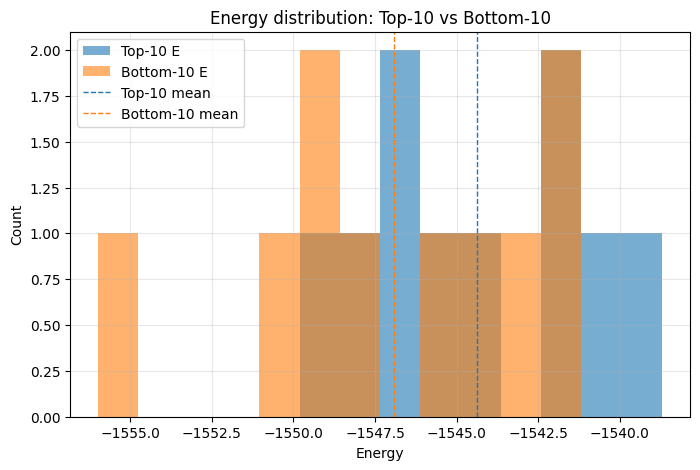

In [43]:
# plot energy distributions on a single axis (no PCA)
top = np.array(E_top10, dtype=float)
bottom = np.array(E_bottom10, dtype=float)

plt.figure(figsize=(8,5))
bins = np.linspace(min(top.min(), bottom.min()) - 1, max(top.max(), bottom.max()) + 1, 15)
plt.hist(top, bins=bins, alpha=0.6, color='tab:blue', label='Top-10 E')
plt.hist(bottom, bins=bins, alpha=0.6, color='tab:orange', label='Bottom-10 E')

plt.axvline(top.mean(), color='tab:blue', linestyle='--', linewidth=1, label='Top-10 mean')
plt.axvline(bottom.mean(), color='tab:orange', linestyle='--', linewidth=1, label='Bottom-10 mean')

plt.xlabel('Energy')
plt.ylabel('Count')
plt.title('Energy distribution: Top-10 vs Bottom-10')
plt.legend()
plt.grid(alpha=0.3)
plt.show()